# Split-half analysis — summary

Data: L1_and_L2, FirstReading (Gathering0 + Hunting0 combined).

**Per iteration (i = 0..N-1):**
1. Randomly split subjects into halves A / B, stratified by (batch, L1_or_L2).
2. For each resolution × RT metric × level_type in {`Adv+Ele`, `diff`}:
   - Aggregate the metric across subjects per (text, level) to get one value per text per half.
   - `diff` = Adv − Ele per text (correlation across `n` texts).
   - `Adv+Ele` = Adv and Ele pooled as data points (correlation across `2·n` points).
   - Correlate half A vs half B (Pearson + Spearman).

N (number of iterations) is reported per row in the `n_iter` column of the summary (and printed below). Summary aggregates mean r, 95% CI, and Spearman-Brown corrected `2r / (1+r)` over iterations.

## CI methods

The summary CSV exposes **two** 95% CI methods; plots are written into separate subfolders.

| Method | Columns in summary | Formula | Where it is used in this repo |
|---|---|---|---|
| **Percentile** (non-parametric) | `ci_low`, `ci_high`, `sb_ci_low`, `sb_ci_high` | 2.5% and 97.5% percentiles of r values across iterations. | — (new here) |
| **t-based** (parametric, mean ± t·std) | `ci_low_tstd`, `ci_high_tstd`, `sb_ci_low_tstd`, `sb_ci_high_tstd` | mean ± `t_{0.975, n-1}` · std(r, ddof=1). | `src/utils/stat_analysis/stat_utils.py::get_mean_ci`, called with `sem_or_std='std'` by `src/Correlations/calc_correlations.py::_agg_over_groups` to aggregate bootstrap correlation samples (`agg_folds_correlations`). |

**When they differ.** If r is roughly symmetric around the mean, the two methods agree. For split-half on the `diff` level_type at paragraph resolution (n ≈ 162 texts), individual iterations can produce r very close to ±1 and the distribution of r is skewed — the t-based CI can extend past ±1 while the percentile CI stays in-range. Spearman-Brown `2r/(1+r)` blows up as r → -1, so its CI is much wider under both methods and especially misleading under t-based.

**Other CI functions in this repo.** `src/utils/stat_analysis/stat_utils.py::bootstrap_ci` uses a symmetric normal approximation (mean ± 1.96·std) over bootstrap samples (radius form). That function is defined but not imported elsewhere at the time of writing; the live bootstrap CI calls in the project go through `get_mean_ci`.

**Related plot subfolders.**
- `plots/no_ci/` — bars without error bars.
- `plots/percentile_ci/` — bars with percentile CI.
- `plots/tstd_ci/` — bars with t-based CI (matches the rest of the repo's convention).

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = Path.cwd() / 'results'
summary = pd.read_csv(RESULTS_DIR / 'split_half_summary.csv')
raw = pd.read_csv(RESULTS_DIR / 'split_half_raw_iterations.csv')
N_ITER = int(summary['n_iter'].max())
print(f'N iterations: {N_ITER} | summary rows: {len(summary)} | raw rows: {len(raw)}')
summary.head()

N iterations: 1000 | summary rows: 92 | raw rows: 46000


,metric,resolution,level_type,corr_kind,n_iter,mean_r,ci_low,ci_high,ci_low_tstd,ci_high_tstd,sb_mean_r,sb_ci_low,sb_ci_high,sb_ci_low_tstd,sb_ci_high_tstd,mean_n_texts
0,RegRateFirstPass,paragraph,Adv+Ele,pearson,1000,0.592701,0.361442,0.743072,0.400877,0.784525,0.739287,0.530969,0.852601,0.579213,0.899360,324.0
1,RegRateFirstPass,paragraph,Adv+Ele,spearman,1000,0.573287,0.343622,0.726407,0.375890,0.770683,0.723290,0.511485,0.841525,0.554127,0.892453,324.0
2,RegRateFirstPass,paragraph,diff,pearson,1000,0.123065,-0.304097,0.435291,-0.264943,0.511073,0.153502,-0.873965,0.606555,-0.601130,0.908134,162.0
3,RegRateFirstPass,paragraph,diff,spearman,1000,0.086440,-0.355484,0.413823,-0.313546,0.486426,0.080469,-1.103110,0.585395,-0.772978,0.933916,162.0
4,RegRateFirstPass,sentence,Adv+Ele,pearson,1000,0.801858,0.762674,0.829075,0.768387,0.835328,0.889934,0.865360,0.906551,0.869163,0.910706,1580.0


## Top metrics by reliability (sentence, diff, Pearson)

In [2]:
def top_by(summary, resolution, level_type, corr_kind, n=15):
    sub = summary[(summary.resolution == resolution) & (summary.level_type == level_type) & (summary.corr_kind == corr_kind)]
    return sub.sort_values('mean_r', ascending=False)[['metric', 'mean_r', 'ci_low', 'ci_high', 'ci_low_tstd', 'ci_high_tstd', 'sb_mean_r', 'mean_n_texts', 'n_iter']].head(n).reset_index(drop=True)

top_by(summary, 'sentence', 'diff', 'pearson')

,metric,mean_r,ci_low,ci_high,ci_low_tstd,ci_high_tstd,sb_mean_r,mean_n_texts,n_iter
0,SkipRateTotal,0.488112,0.152474,0.678910,0.208462,0.767762,0.642377,790.0,1000
1,mean_GD,0.477418,0.021515,0.761733,0.077276,0.877561,0.616015,790.0,1000
2,RegRateTotal,0.447406,0.231496,0.566459,0.275562,0.619250,0.612766,790.0,1000
3,mean_NF,0.439135,0.100102,0.646386,0.153469,0.724801,0.594405,790.0,1000
4,SkipRateFirstPass,0.431158,0.137875,0.611876,0.189757,0.672559,0.591071,790.0,1000
5,RegRateFirstPass,0.429593,0.288533,0.515655,0.317994,0.541192,0.598679,790.0,1000
6,mean_nonzero_TF,0.417570,0.059909,0.640802,0.105861,0.729280,0.569232,790.0,1000
7,mean_FirstPassGD,0.368054,0.035765,0.571502,0.082590,0.653518,0.519182,790.0,1000
8,mean_nonzero_FF,0.276872,-0.149345,0.556139,-0.095367,0.649111,0.392139,790.0,1000
9,mean_FD,0.267955,-0.169538,0.558031,-0.121174,0.657084,0.375898,790.0,1000


## Paragraph, diff, Pearson

In [3]:
top_by(summary, 'paragraph', 'diff', 'pearson')

,metric,mean_r,ci_low,ci_high,ci_low_tstd,ci_high_tstd,sb_mean_r,mean_n_texts,n_iter
0,reading_speed,0.404219,-0.051276,0.693811,-0.001784,0.810223,0.538356,162.0,1000
1,SkipRateTotal,0.373306,-0.161001,0.740107,-0.111276,0.857889,0.486888,162.0,1000
2,mean_nonzero_TF,0.340675,-0.207476,0.715463,-0.146149,0.827500,0.445871,162.0,1000
3,mean_NF,0.340630,-0.163702,0.689090,-0.107439,0.788698,0.456023,162.0,1000
4,SkipRateFirstPass,0.336805,-0.170032,0.673566,-0.100973,0.774584,0.453425,162.0,1000
5,mean_GD,0.334108,-0.328990,0.806996,-0.281468,0.949684,0.387090,162.0,1000
6,RegRateTotal,0.278824,-0.153650,0.597638,-0.106175,0.663823,0.393079,162.0,1000
7,mean_FD,0.268510,-0.401596,0.777905,-0.373012,0.910032,0.273598,162.0,1000
8,mean_FirstPassGD,0.265103,-0.360052,0.737281,-0.331634,0.861839,0.294988,162.0,1000
9,mean_HigherPassFixation,0.255265,-0.121942,0.538700,-0.089468,0.599999,0.370635,162.0,1000


## Adv+Ele pooled (sentence, Pearson)

Half A vs half B across pooled (text × level) points — this captures the within-level ranking consistency of the metric across halves.

In [4]:
top_by(summary, 'sentence', 'Adv+Ele', 'pearson')

,metric,mean_r,ci_low,ci_high,ci_low_tstd,ci_high_tstd,sb_mean_r,mean_n_texts,n_iter
0,mean_NF,0.859518,0.775135,0.904196,0.795084,0.923952,0.924111,1580.0,1000
1,SkipRateTotal,0.848124,0.763823,0.899141,0.776867,0.919382,0.917396,1580.0,1000
2,mean_nonzero_TF,0.829985,0.728591,0.887721,0.747064,0.912906,0.906498,1580.0,1000
3,mean_GD,0.818176,0.662108,0.904464,0.692466,0.943886,0.898576,1580.0,1000
4,RegRateTotal,0.817304,0.753314,0.853622,0.768088,0.866521,0.899256,1580.0,1000
5,RegRateFirstPass,0.801858,0.762674,0.829075,0.768387,0.835328,0.889934,1580.0,1000
6,SkipRateFirstPass,0.800150,0.713009,0.854540,0.727612,0.872688,0.888504,1580.0,1000
7,mean_HigherPassFixation,0.697780,0.629343,0.740960,0.639464,0.756097,0.821624,1580.0,1000
8,mean_FirstPassGD,0.676029,0.526524,0.763325,0.551982,0.800076,0.804925,1580.0,1000
9,mean_FD,0.503396,0.250729,0.672755,0.281687,0.725105,0.661567,1580.0,1000


## Comparing paragraph vs sentence (diff, Pearson)

In [5]:
pivot = summary[(summary.level_type == 'diff') & (summary.corr_kind == 'pearson')].pivot(index='metric', columns='resolution', values='mean_r').sort_values('sentence', ascending=False)
pivot.round(3)

resolution,paragraph,sentence
metric,,
SkipRateTotal,0.373,0.488
mean_GD,0.334,0.477
RegRateTotal,0.279,0.447
mean_NF,0.341,0.439
SkipRateFirstPass,0.337,0.431
RegRateFirstPass,0.123,0.430
mean_nonzero_TF,0.341,0.418
mean_FirstPassGD,0.265,0.368
mean_nonzero_FF,0.232,0.277


## Comparing paragraph vs sentence (Adv+Ele, Pearson)

In [6]:
pivot = summary[(summary.level_type == 'Adv+Ele') & (summary.corr_kind == 'pearson')].pivot(index='metric', columns='resolution', values='mean_r').sort_values('sentence', ascending=False)
pivot.round(3)

resolution,paragraph,sentence
metric,,
mean_NF,0.737,0.860
SkipRateTotal,0.673,0.848
mean_nonzero_TF,0.730,0.830
mean_GD,0.617,0.818
RegRateTotal,0.767,0.817
RegRateFirstPass,0.593,0.802
SkipRateFirstPass,0.614,0.800
mean_HigherPassFixation,0.702,0.698
mean_FirstPassGD,0.574,0.676


## Heatmap of mean r across (metric × level_type × resolution)

saved plots/heatmaps/heatmap_main_raw_pearson.pdf


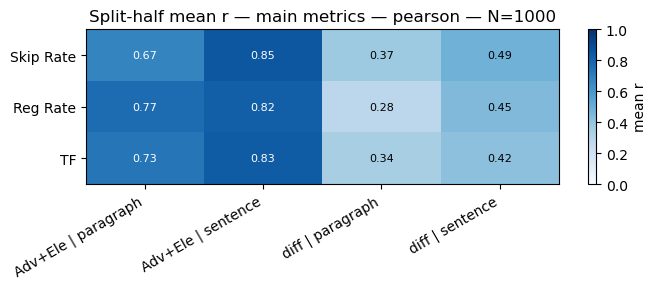

saved plots/heatmaps/heatmap_main_raw_spearman.pdf


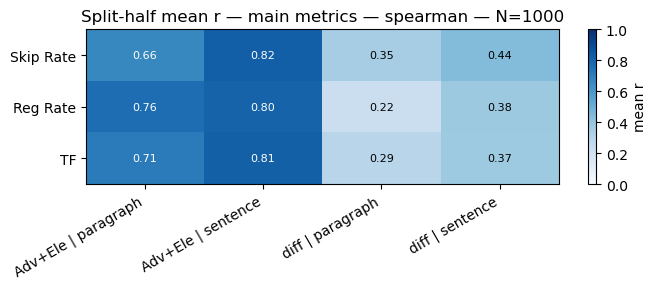

saved plots/heatmaps/heatmap_main_sb_pearson.pdf


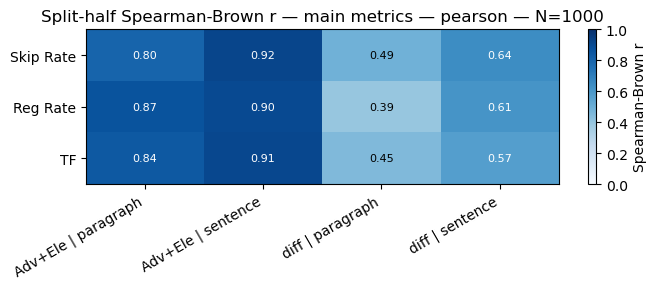

saved plots/heatmaps/heatmap_main_sb_spearman.pdf


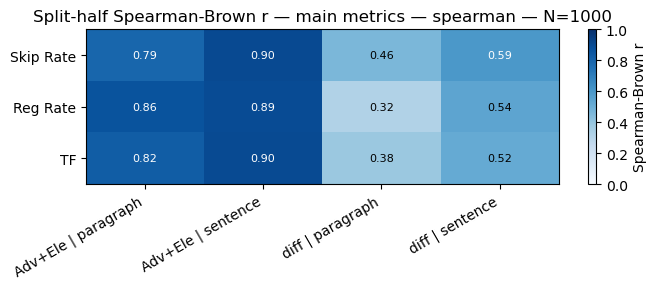

saved plots/heatmaps/heatmap_main+sm_raw_pearson.pdf


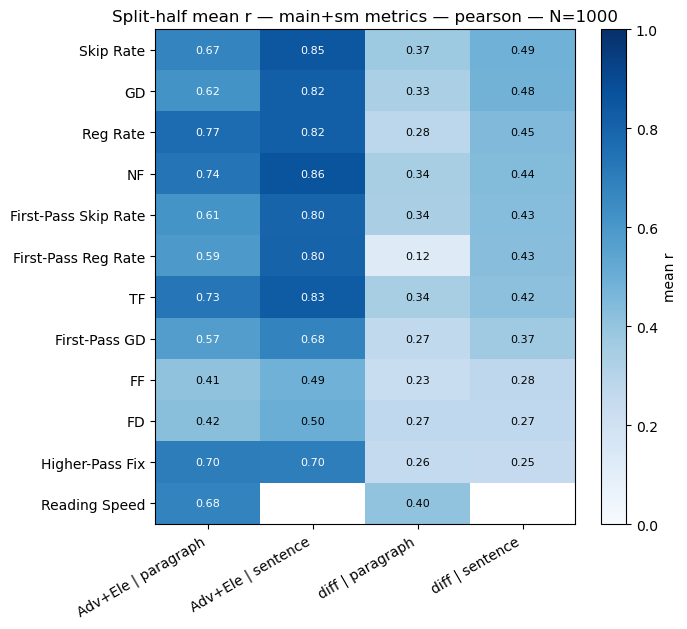

saved plots/heatmaps/heatmap_main+sm_raw_spearman.pdf


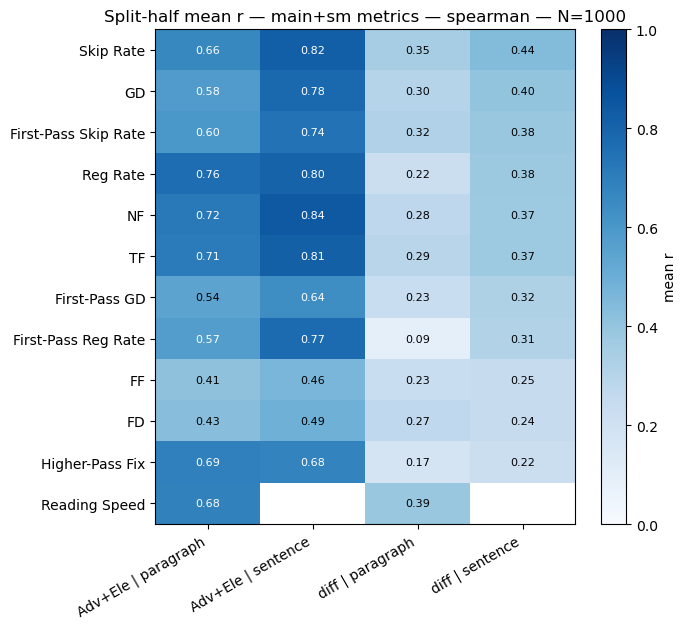

saved plots/heatmaps/heatmap_main+sm_sb_pearson.pdf


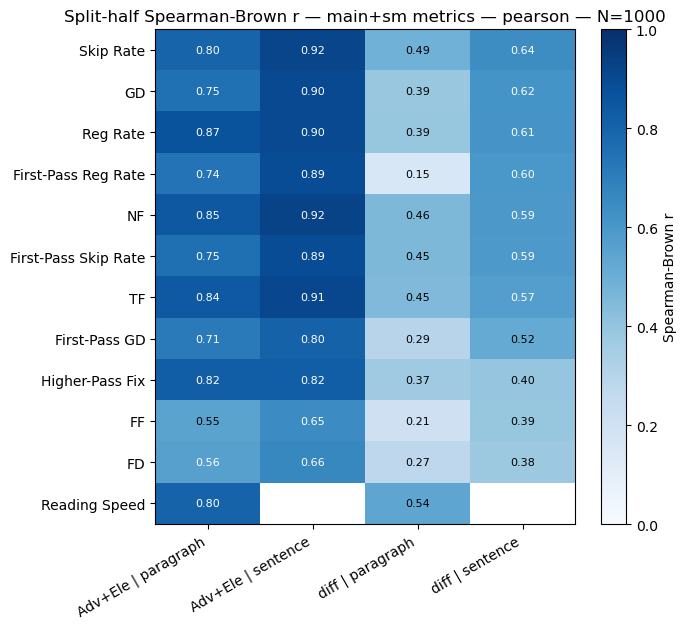

saved plots/heatmaps/heatmap_main+sm_sb_spearman.pdf


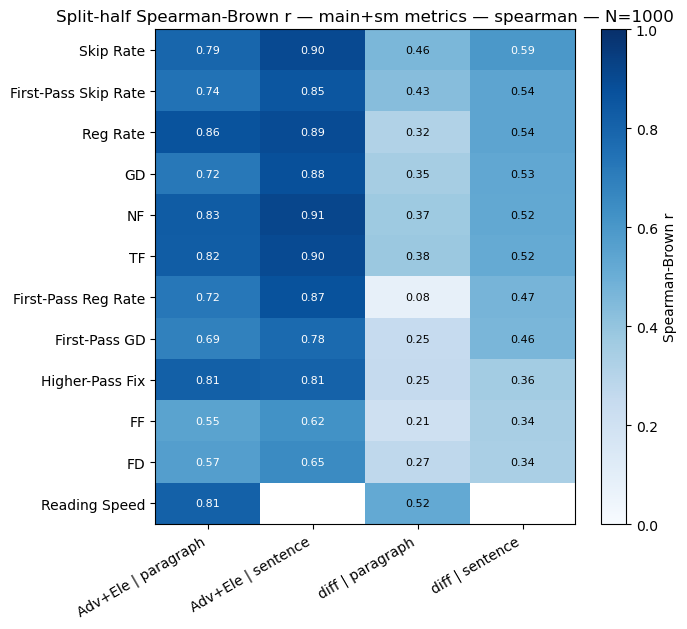

In [7]:
from src.Correlations.analysis.split_half.plots import METRIC_LABELS
from src.Correlations.define_cols import MAIN_RT_COLS, SM_RT_COLS

HEATMAP_DIR = RESULTS_DIR / 'plots' / 'heatmaps'
HEATMAP_DIR.mkdir(parents=True, exist_ok=True)

# Clear stale PDFs that were saved directly under results/ before the move.
for old_pdf in RESULTS_DIR.glob('heatmap_*.pdf'):
    old_pdf.unlink()

METRIC_SUBSETS = {
    'main':     MAIN_RT_COLS,
    'main+sm':  MAIN_RT_COLS + SM_RT_COLS,
}
R_VARIANTS = {
    'raw': 'mean_r',        # raw split-half correlation
    'sb':  'sb_mean_r',     # Spearman-Brown corrected: 2r / (1 + r)
}
R_LABEL = {'raw': 'mean r', 'sb': 'Spearman-Brown r'}

for subset_name, metrics in METRIC_SUBSETS.items():
    for variant, value_col in R_VARIANTS.items():
        for corr_kind in ['pearson', 'spearman']:
            sub = summary[(summary.corr_kind == corr_kind) & (summary.metric.isin(metrics))].copy()
            sub['col'] = sub['level_type'] + ' | ' + sub['resolution']
            col_order = [f'{lt} | {res}' for lt in ['Adv+Ele', 'diff'] for res in ['paragraph', 'sentence']]
            col_order = [c for c in col_order if c in sub['col'].unique()]
            pivot = sub.pivot_table(index='metric', columns='col', values=value_col)[col_order]
            pivot = pivot.sort_values(by='diff | sentence', ascending=False)
            pivot.index = [METRIC_LABELS.get(m, m) for m in pivot.index]

            fig, ax = plt.subplots(figsize=(7, max(3, 0.45 * len(pivot) + 1)))
            im = ax.imshow(pivot.values, cmap='Blues', vmin=0, vmax=1, aspect='auto')
            ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
            ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
            for i in range(pivot.shape[0]):
                for j in range(pivot.shape[1]):
                    v = pivot.values[i, j]
                    if not np.isnan(v):
                        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                                color='white' if v > 0.55 else 'black', fontsize=8)
            fig.colorbar(im, ax=ax, label=R_LABEL[variant])
            ax.set_title(f'Split-half {R_LABEL[variant]} — {subset_name} metrics — {corr_kind} — N={N_ITER}')
            fig.tight_layout()
            out_path = HEATMAP_DIR / f'heatmap_{subset_name}_{variant}_{corr_kind}.pdf'
            fig.savefig(out_path)
            print(f'saved {out_path.relative_to(RESULTS_DIR)}')
            plt.show()

## Shape of the r distribution per metric (sentence, diff, Pearson)

Quick visual to judge whether the r distribution across iterations is roughly symmetric (supporting the t-based CI) or skewed (favoring the percentile CI).

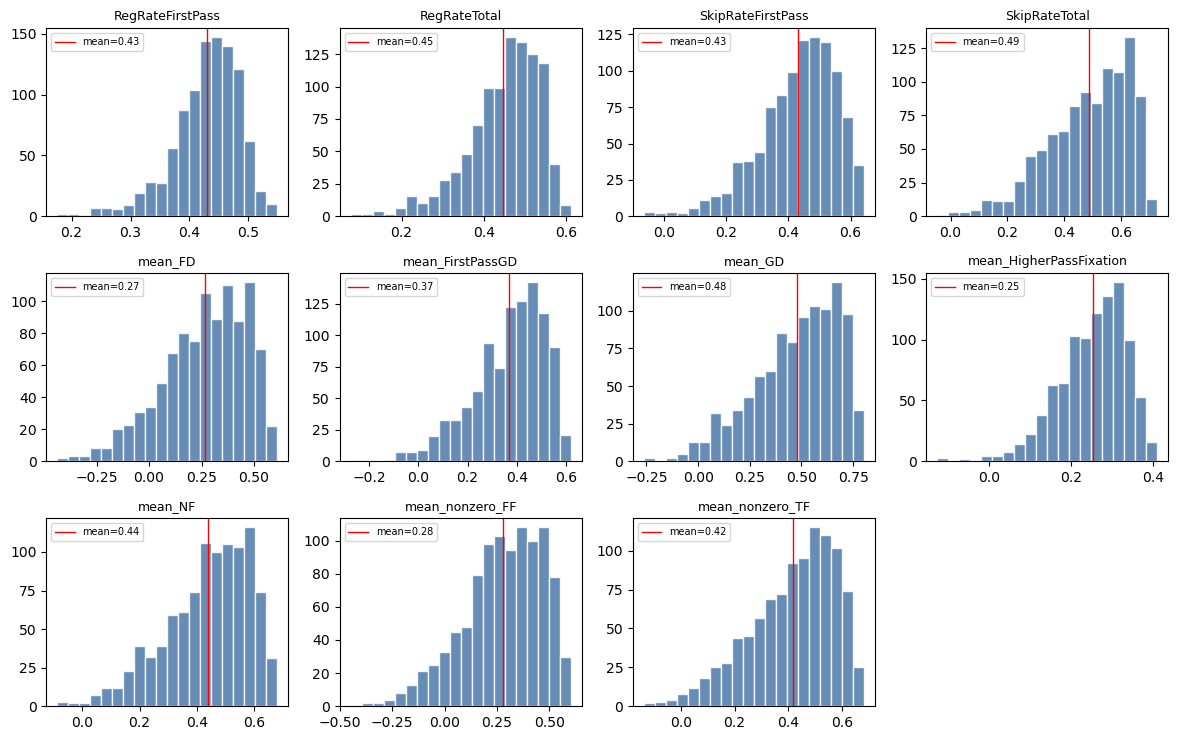

In [8]:
sub = raw[(raw.resolution == 'sentence') & (raw.level_type == 'diff')]
metrics = sorted(sub.metric.unique())
ncols = 4; nrows = int(np.ceil(len(metrics)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 2.5*nrows))
axes = np.atleast_2d(axes)
for idx, m in enumerate(metrics):
    ax = axes[idx//ncols, idx%ncols]
    rs = sub[sub.metric == m].pearson_r.dropna()
    ax.hist(rs, bins=20, color='#4C78A8', alpha=0.85, edgecolor='white')
    ax.axvline(rs.mean(), color='red', linewidth=1, label=f'mean={rs.mean():.2f}')
    ax.set_title(m, fontsize=9)
    ax.legend(fontsize=7)
for k in range(len(metrics), nrows*ncols):
    axes[k//ncols, k%ncols].set_visible(False)
fig.tight_layout(); plt.show()

## Takeaways

- Sentence resolution produces tighter and higher split-half correlations than paragraph resolution for every metric (≈ 790 sentences vs ≈ 162 paragraphs per split).
- At the sentence resolution, `SkipRateTotal`, `mean_GD`, `mean_nonzero_TF`, and `mean_NF` have the highest reliability on the diff level_type.
- `reading_speed` (paragraph only) also has competitive reliability.
- Spearman-Brown correction roughly maps a half-half r of 0.45–0.50 to a full-sample reliability estimate around 0.60–0.65.